In [1]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

kf = KFold(n_splits=10, shuffle=True)

scores = cross_val_score(gnb, X, y, cv=kf)
mean_score = scores.mean()
std_score = scores.std()

print(f"Reference mean cross-validation score: {mean_score:.2f} ± {std_score:.2f}")

Reference mean cross-validation score: 0.94 ± 0.05


In [2]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import multivariate_normal

class myNormalBayes(BaseEstimator, ClassifierMixin):
  """
  cov_types: full, naive, complete_set
  """
  def __init__(self, cov_type: str = "full"):

    if cov_type not in ["full", "naive", "complete_set"]:
      raise ValueError("Invalid covariance type. Choose from 'full', 'naive', or 'complete_set'.")

    self.cov_type = cov_type

  def fit(self, X: np.ndarray, y: np.ndarray) -> None:
    
    self.X = X
    self.y = y

    self.X0, self.X1 = self._get_classes(X, y)

    self.prior0 = len(self.X0) / len(X)
    self.prior1 = len(self.X1) / len(X)

    self.mean0 = np.mean(self.X0, axis=0)
    self.mean1 = np.mean(self.X1, axis=0)

    if self.cov_type == "full":
      self._fit_full()

    elif self.cov_type == "naive":
      self._fit_naive()

    elif self.cov_type == "complete_set":
      self._fit_complete_set()

    else:
      raise ValueError(f"Unknown covariance type: {self.cov_type}")
    
  def predict(self, X: np.ndarray) -> np.ndarray:
    """
    Predict the class labels for the input data.
    Args:
      X: The input data.
    Returns:
      np.ndarray: The predicted class labels.
    """
    
    prob0 = multivariate_normal.pdf(X, mean=self.mean0, cov=self.cov0)
    prob1 = multivariate_normal.pdf(X, mean=self.mean1, cov=self.cov1)

    return np.where(prob0 * self.prior0 > prob1 * self.prior1, 0, 1)
  
  def likelihoods(self, X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculate the likelihoods for each class.
    Args:
      X: The input data.
      y: The target vector.
    Returns:
      tuple: (likelihood0, likelihood1)
    """

    self.fit(X, y)
    
    likelihood0 = multivariate_normal.pdf(X, mean=self.mean0, cov=self.cov0)
    likelihood1 = multivariate_normal.pdf(X, mean=self.mean1, cov=self.cov1)

    Qsum = np.sum(likelihood0 + likelihood1)

    Q0 = likelihood0 / Qsum
    Q1 = likelihood1 / Qsum

    return Q0, Q1
  

  def _get_classes(self, X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Get the classes and their respective indices from the dataset.
    Args:
      X: The feature matrix.
      y: The target vector.
    Returns:
      tuple: (X0, X1)
    """

    classes = np.unique(y)
    if len(classes) != 2:
      raise ValueError("Only binary classification supported")
    
    X0 = X[y == classes[0]]
    X1 = X[y == classes[1]]
    
    return X0, X1
  
  def _fit_full(self) -> None:
    """
    Fit the model using full covariance matrices.
    """

    self.cov0 = np.cov(self.X0, rowvar=False)
    self.cov1 = np.cov(self.X1, rowvar=False)

  def _fit_naive(self) -> None:
    """
    Fit the model using naive covariance matrices (diagonal covariance).
    """

    self.cov0 = np.diag(np.var(self.X0, axis=0))
    self.cov1 = np.diag(np.var(self.X1, axis=0))

  def _fit_complete_set(self) -> None:
    """
    Fit the model using complete set covariance matrices.
    """

    self.cov = np.cov(np.vstack((self.X0, self.X1)), rowvar=False)

    self.cov0 = self.cov
    self.cov1 = self.cov

In [3]:
full_model = myNormalBayes(cov_type="full")
naive_model = myNormalBayes(cov_type="naive")
complete_set_model = myNormalBayes(cov_type="complete_set")

from feature_engine.selection import DropCorrelatedFeatures

X = DropCorrelatedFeatures().fit_transform(X)

full_scores = cross_val_score(full_model, X, y, cv=kf, scoring="accuracy")
full_mean_score = full_scores.mean()
full_std_score = full_scores.std()

naive_scores = cross_val_score(naive_model, X, y, cv=kf, scoring="accuracy")
naive_mean_score = naive_scores.mean()
naive_std_score = naive_scores.std()

complete_set_scores = cross_val_score(complete_set_model, X, y, cv=kf, scoring="accuracy")
complete_set_mean_score = complete_set_scores.mean()
complete_set_std_score = complete_set_scores.std()

print(f"Full covariance model mean cross-validation score: {full_mean_score:.2f} ± {full_std_score:.2f}")
print(f"Naive covariance model mean cross-validation score: {naive_mean_score:.2f} ± {naive_std_score:.2f}")
print(f"Complete set covariance model mean cross-validation score: {complete_set_mean_score:.2f} ± {complete_set_std_score:.2f}")

Full covariance model mean cross-validation score: 0.95 ± 0.03
Naive covariance model mean cross-validation score: 0.90 ± 0.04
Complete set covariance model mean cross-validation score: 0.91 ± 0.03


In [4]:
def sk_likelihoods(gnb: GaussianNB, X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
  """
  Calculate the class conditional likelihoods for each class.
  Args:
    gnb: The fitted GaussianNB model.
    X: The input data.
    y: The target vector.
  Returns:
    tuple: (class_cond_lik0, class_cond_lik1)
  """
  gnb.fit(X, y)
  jll = gnb._joint_log_likelihood(X)
  log_prior = np.log(gnb.class_prior_)
  log_lik = jll - log_prior
  class_cond_lik = np.exp(log_lik)

  Qsum = np.sum(class_cond_lik)

  Q0 = class_cond_lik[:, 0] / Qsum
  Q1 = class_cond_lik[:, 1] / Qsum

  return Q0, Q1

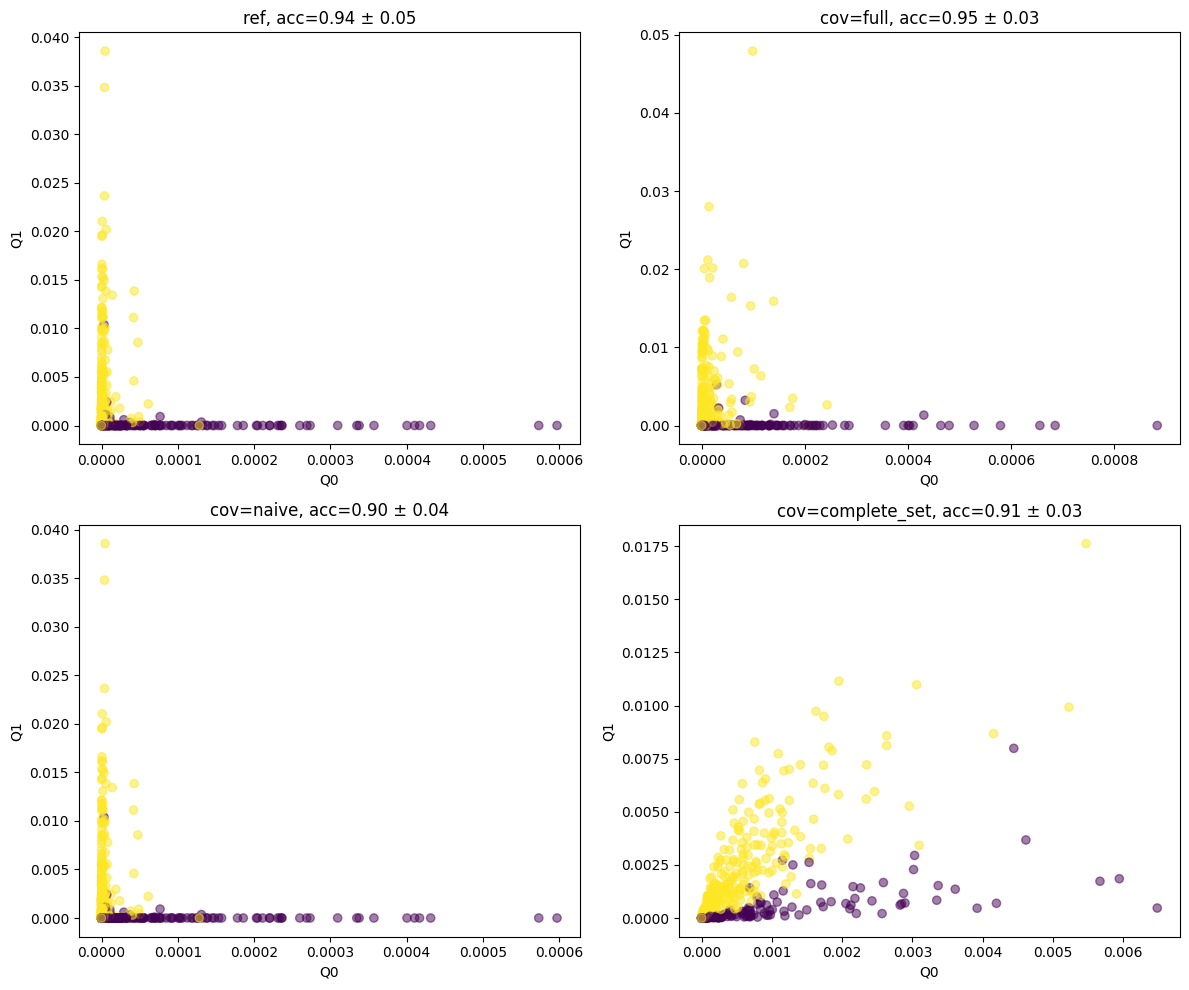

In [5]:
import matplotlib.pyplot as plt

skQ0, skQ1 = sk_likelihoods(gnb, X, y)

fullQ0, fullQ1 = full_model.likelihoods(X, y)
naiveQ0, naiveQ1 = naive_model.likelihoods(X, y)
complete_setQ0, complete_setQ1 = complete_set_model.likelihoods(X, y)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plot for skQ0 vs skQ1
axes[0, 0].scatter(skQ0, skQ1, c=y, alpha=0.5)
axes[0, 0].set_title(f'ref, acc={mean_score:.2f} ± {std_score:.2f}')
axes[0, 0].set_xlabel('Q0')
axes[0, 0].set_ylabel('Q1')

# Scatter plot for fullQ0 vs fullQ1
axes[0, 1].scatter(fullQ0, fullQ1, c=y, alpha=0.5)
axes[0, 1].set_title(f'cov=full, acc={full_mean_score:.2f} ± {full_std_score:.2f}')
axes[0, 1].set_xlabel('Q0')
axes[0, 1].set_ylabel('Q1')
# Scatter plot for naiveQ0 vs naiveQ1
axes[1, 0].scatter(naiveQ0, naiveQ1, c=y, alpha=0.5)
axes[1, 0].set_title(f'cov=naive, acc={naive_mean_score:.2f} ± {naive_std_score:.2f}')
axes[1, 0].set_xlabel('Q0')
axes[1, 0].set_ylabel('Q1')

# Scatter plot for complete_setQ0 vs complete_setQ1
axes[1, 1].scatter(complete_setQ0, complete_setQ1, c=y, alpha=0.5)
axes[1, 1].set_title(f'cov=complete_set, acc={complete_set_mean_score:.2f} ± {complete_set_std_score:.2f}')
axes[1, 1].set_xlabel('Q0')
axes[1, 1].set_ylabel('Q1')

plt.tight_layout()
plt.show()

We note, both from accuracy score and likelihood space, that the full covariance model is the closest to the reference model. Since it considers linear correlation between the features, it achieves slightly better results. The custom naive approach produces a similar likelihood space, as it also considers samples from each class separately. Its accuracy is lower, maybe because of a lack of regularization. Also, differently from the first previous model, it is not degraded by highly correlated features. Finally, the approach in which the complete set is considered for the covariance computation achieves an intermediate accuracy, likely because the correlations in each class are similar to the correlations in the complete set (note that the correlation filter applied over the entire set is enough for the per-class covariance computation). However, its likelihood space is the most different, which contradicts the previous conclusion. Further investigation is needed.